<a href="https://colab.research.google.com/github/MaheeshaSawandi/Safehood/blob/Prediction-Model/LR1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

import joblib

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df = pd.read_excel(
    "/content/drive/MyDrive/SafeHood_ML/Dataset/processed_dataset.xlsx"
)

df.head()

,Location,Year,Month,Crime_Count,Average_Severity,Maximum_Severity,Next_Month_Crime,Future_Risk
0,Abhayapura,2016,1,26,6.846154,10,33.0,High
1,Abhayapura,2016,2,33,6.606061,10,19.0,Medium
2,Abhayapura,2016,3,19,7.157895,10,21.0,Medium
3,Abhayapura,2016,4,21,7.000000,10,15.0,Medium
4,Abhayapura,2016,5,15,6.000000,10,28.0,Medium


In [ ]:
print(df.shape)

df.info()

(5638, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5638 entries, 0 to 5637
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Location          5638 non-null   object 
 1   Year              5638 non-null   int64  
 2   Month             5638 non-null   int64  
 3   Crime_Count       5638 non-null   int64  
 4   Average_Severity  5638 non-null   float64
 5   Maximum_Severity  5638 non-null   int64  
 6   Next_Month_Crime  5570 non-null   float64
 7   Future_Risk       5638 non-null   object 
dtypes: float64(2), int64(4), object(2)
memory usage: 352.5+ KB


In [ ]:
df.isnull().sum()

,0
Location,0
Year,0
Month,0
Crime_Count,0
Average_Severity,0
Maximum_Severity,0
Next_Month_Crime,68
Future_Risk,0


In [ ]:
df = df.dropna()

In [ ]:
df["Future_Risk"].value_counts()

,count
Future_Risk,
Medium,2737
Low,2557
High,276


In [ ]:
encoder = LabelEncoder()

df["Location_Code"] = encoder.fit_transform(
    df["Location"]
)

In [ ]:
features = [

"Location_Code",

"Year",

"Month",

"Crime_Count",

"Average_Severity",

"Maximum_Severity"

]

In [ ]:
X = df[features]

y = df["Future_Risk"]

In [ ]:
train = df[df["Year"] <= 2023]


test = df[df["Year"] > 2023]

In [ ]:
X_train = train[features]

X_test = test[features]


y_train = train["Future_Risk"]

y_test = test["Future_Risk"]

In [ ]:
print(
"Training:",
X_train.shape
)


print(
"Testing:",
X_test.shape
)

Training: (4539, 6)
Testing: (1031, 6)


In [ ]:
scaler = StandardScaler()


X_train_scaled = scaler.fit_transform(
    X_train
)


X_test_scaled = scaler.transform(
    X_test
)

In [ ]:
lr_01 = LogisticRegression(

    C=0.1,

    max_iter=1000,

    random_state=42

)


lr_01.fit(

    X_train_scaled,

    y_train

)


pred_01 = lr_01.predict(

    X_test_scaled

)

In [ ]:
print(
"Accuracy:",
accuracy_score(
    y_test,
    pred_01
)
)


print(
"Precision:",
precision_score(
    y_test,
    pred_01,
    average="weighted"
)
)


print(
"Recall:",
recall_score(
    y_test,
    pred_01,
    average="weighted"
)
)


print(
"F1:",
f1_score(
    y_test,
    pred_01,
    average="weighted"
)
)

Accuracy: 0.9359844810863239
Precision: 0.8868417443889545
Recall: 0.9359844810863239
F1: 0.9103448465880496


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
print(
classification_report(
    y_test,
    pred_01
)
)

              precision    recall  f1-score   support

        High       0.00      0.00      0.00        56
         Low       0.98      0.99      0.99       445
      Medium       0.90      0.99      0.94       530

    accuracy                           0.94      1031
   macro avg       0.63      0.66      0.64      1031
weighted avg       0.89      0.94      0.91      1031



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


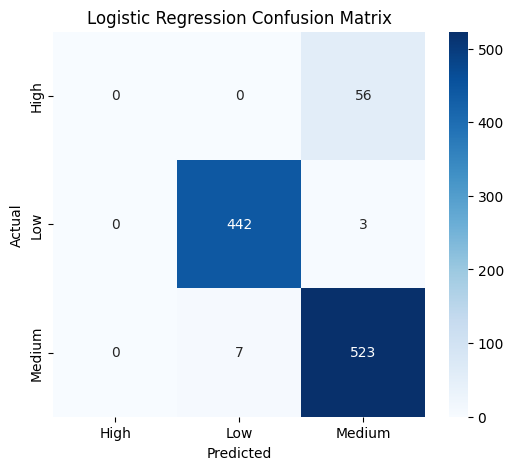

In [ ]:
cm = confusion_matrix(
    y_test,
    pred_01
)


plt.figure(figsize=(6,5))


sns.heatmap(

    cm,

    annot=True,

    fmt="d",

    cmap="Blues",

    xticklabels=lr_01.classes_,

    yticklabels=lr_01.classes_

)


plt.xlabel(
    "Predicted"
)

plt.ylabel(
    "Actual"
)

plt.title(
    "Logistic Regression Confusion Matrix"
)

plt.show()

In [ ]:
joblib.dump(

    lr_01,

    "/content/drive/MyDrive/SafeHood_ML/Models/logistic_regression_model1.pkl"

)


joblib.dump(

    scaler,

    "/content/drive/MyDrive/SafeHood_ML/Models/scaler_lr1.pkl"

)

['/content/drive/MyDrive/SafeHood_ML/Models/scaler_lr1.pkl']